In [4]:
#Exercise 1
import scipy as sp
import numpy as np

In [6]:
#Exercise 2
data = [12, 15, 13, 12, 18, 20, 22, 21]
print("Mean:", sp.stats.tmean(data))
print("Median:", np.median(data))
print("Standard Deviation:", sp.stats.tstd(data))
print("Variance:", sp.stats.tvar(data))

Mean: 16.625
Median: 16.5
Standard Deviation: 4.138236339311712
Variance: 17.125


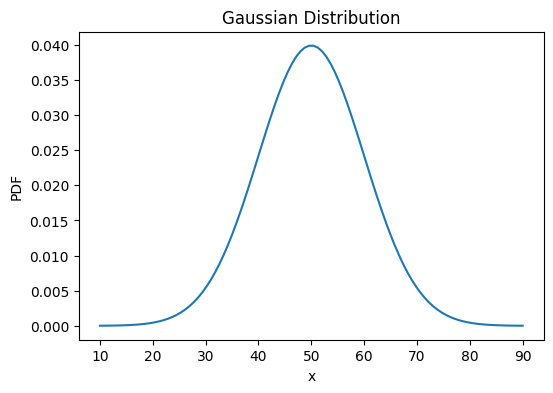

In [11]:
#Ex 3
import matplotlib.pyplot as plt
from scipy.stats import norm
mean,stddev=50,10
x_gaussian = np.linspace(mean - 4*stddev, mean + 4*stddev, 100)
normal=sp.stats.norm(mean,stddev)
pdf_gaussian = normal.pdf(x_gaussian)
plt.figure(figsize=(6, 4))
plt.plot(x_gaussian, pdf_gaussian)
plt.xlabel('x')
plt.ylabel('PDF')
plt.title('Gaussian Distribution')
plt.show()


In [14]:

#Ex4 Ttest
from scipy.stats import ttest_ind,t
data1 = np.random.normal(50, 10, 100)
data2 = np.random.normal(60, 10, 100)

mean1, mean2 = np.mean(data1), np.mean(data2)
print("Mean of data1:", mean1)
print("Mean of data2:", mean2)

t_statistic, p_value = ttest_ind(data1, data2)
print("T-statistic:", t_statistic)
print("P-value:", p_value)
alpha = 0.05
df=len(data1) + len(data2) - 2
print("Degrees of freedom:", df)
critical_value = t.ppf(1 - alpha/2, df)
print("Critical value:", critical_value)

print(f"Calculated |T| = {abs(t_statistic):.3f}")
print(f"Critical |T|   = {critical_value:.3f}")
if abs(t_statistic) > critical_value:
    print("Reject the null hypothesis: The means are significantly different.")
    print("The reason is that the calculated T-statistic is greater than the critical value.")
else:    
    print("Fail to reject the null hypothesis: The means are not significantly different.")
    print("The reason is that the calculated T-statistic is not greater than the critical value.")

#Using p-value
if p_value < alpha:
    print("Reject the null hypothesis: The means are significantly different.")
    print(f"P-value = {p_value:.3f} < alpha = {alpha}")
else:
    print("Fail to reject the null hypothesis: The means are not significantly different.")
    print(f"P-value = {p_value:.3f} >= alpha = {alpha}")


Mean of data1: 47.4296007426166
Mean of data2: 60.09553854387013
T-statistic: -10.025005058280254
P-value: 2.165352360602048e-19
Degrees of freedom: 198
Critical value: 1.9720174778338955
Calculated |T| = 10.025
Critical |T|   = 1.972
Reject the null hypothesis: The means are significantly different.
The reason is that the calculated T-statistic is greater than the critical value.
Reject the null hypothesis: The means are significantly different.
P-value = 0.000 < alpha = 0.05


In [18]:
#Ex5 Linear Regression
house_sizes= [50, 70, 80, 100, 120]
house_prices= [150000, 200000, 210000, 250000, 280000]

slope, intercept, r_value, p_value, std_err = sp.stats.linregress(house_sizes, house_prices)
print("Slope:", slope)
print("Intercept:", intercept)

print("Predicted price for a 90 sqm house: ${:.2f}".format(slope * 90 + intercept))

print("Since the slope is positive, it indicates that there is a positive relationship between house size and price. As the size of the house increases, the price tends to increase as well. Since the number is large, it suggests that the relationship is strong, meaning that house size is a good predictor of house price in this dataset.")

Slope: 1828.7671232876712
Intercept: 64383.56164383562
Predicted price for a 90 sqm house: $228972.60


In [20]:
#Ex6 ANOVA
fertilizer_1= [5, 6, 7, 6, 5]
fertilizer_2= [7, 8, 7, 9, 8]
fertilizer_3= [4, 5, 4, 3, 4]

f_statistic, p_value = sp.stats.f_oneway(fertilizer_1, fertilizer_2, fertilizer_3)
print("F-statistic:", f_statistic)
print("P-value:", p_value)
alpha = 0.05
if p_value < alpha:
    print("Reject the null hypothesis: The fertilizers have significantly different effects on plant growth.")
else:
    print("Fail to reject the null hypothesis: The fertilizers do not have significantly different effects on plant growth.")

print("Based on the P-value, do the fertilizers have significantly different effects on plant growth?")
if p_value < alpha:
    print("Yes, because the P-value is less than 0.05.")
else:
    print("No, because the P-value is not less than 0.05.")

print("Explain what would happen if the P-value were greater than 0.05.")
print("If the P-value were greater than 0.05, we would fail to reject the null hypothesis, meaning there would not be enough evidence to conclude that the fertilizers differ significantly in their effects.")


F-statistic: 28.52631578947368
P-value: 2.7542672098048448e-05
Reject the null hypothesis: The fertilizers have significantly different effects on plant growth.
Based on the P-value, do the fertilizers have significantly different effects on plant growth?
Yes, because the P-value is less than 0.05.
Explain what would happen if the P-value were greater than 0.05.
If the P-value were greater than 0.05, we would fail to reject the null hypothesis, meaning there would not be enough evidence to conclude that the fertilizers differ significantly in their effects.


In [23]:
import pandas as pd

#Ex7
#Ex7

# Define a binomial distribution for 10 coin flips with probability of heads = 0.5
n = 10
p = 0.5
binom_dist = sp.stats.binom(n, p)

# Calculate probability of exactly 5 heads
prob_exact_5 = binom_dist.pmf(5)
print("Probability of exactly 5 heads in 10 coin flips:", prob_exact_5)

# Calculate probabilities for a few different numbers of successes
for k in [0, 1, 2, 5, 8, 10]:
    prob_k = binom_dist.pmf(k)
    print(f"P(X = {k}) = {prob_k:.4f}")

# Show the full distribution for all possible numbers of successes
print("\nFull binomial distribution probabilities:")
for k in range(n + 1):
    print(f"Number of successes = {k}: P = {binom_dist.pmf(k):.4f}")

# Exercise 8: Correlation Coefficients (Optional)
data = pd.DataFrame({
    'age': [23, 25, 30, 35, 40],
    'income': [35000, 40000, 50000, 60000, 70000]
})

# Calculate Pearson and Spearman correlation coefficients
pearson_corr, pearson_p = sp.stats.pearsonr(data['age'], data['income'])
spearman_corr, spearman_p = sp.stats.spearmanr(data['age'], data['income'])

print("\nPearson correlation coefficient:", pearson_corr)
print("Pearson p-value:", pearson_p)

print("Spearman correlation coefficient:", spearman_corr)
print("Spearman p-value:", spearman_p)

Probability of exactly 5 heads in 10 coin flips: 0.24609375
P(X = 0) = 0.0010
P(X = 1) = 0.0098
P(X = 2) = 0.0439
P(X = 5) = 0.2461
P(X = 8) = 0.0439
P(X = 10) = 0.0010

Full binomial distribution probabilities:
Number of successes = 0: P = 0.0010
Number of successes = 1: P = 0.0098
Number of successes = 2: P = 0.0439
Number of successes = 3: P = 0.1172
Number of successes = 4: P = 0.2051
Number of successes = 5: P = 0.2461
Number of successes = 6: P = 0.2051
Number of successes = 7: P = 0.1172
Number of successes = 8: P = 0.0439
Number of successes = 9: P = 0.0098
Number of successes = 10: P = 0.0010

Pearson correlation coefficient: 0.9996907452347202
Pearson p-value: 6.528122732008983e-06
Spearman correlation coefficient: 0.9999999999999999
Spearman p-value: 1.4042654220543672e-24
